# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install datasets scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.9 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [2]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [6]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("SetFit/ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...


train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [8]:
# Preprocess
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])

y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 5000


### Exercise A.1: Train a News Classifier

In [9]:

clf_ag = LogisticRegression(max_iter=1000)

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8810
  F1 (macro): 0.8803


In [10]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.88      0.89       493
      Sports       0.94      0.96      0.95       504
    Business       0.84      0.82      0.83       474
    Sci/Tech       0.85      0.86      0.86       529

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [15]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")

from datasets import load_dataset

lex_glue = load_dataset("coastalcph/lex_glue","ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue["train"])
lex_test = pd.DataFrame(lex_glue["test"])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...


ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 1500, Test: 500

Columns: ['text', 'labels']


In [16]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [17]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [26]:
# TODO: Complete the legal document classifier using Bag of Words
import nltk
nltk.download('punkt_tab')

# TODO: Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
# YOUR CODE HERE
bow_legal = CountVectorizer(
    max_features=5000,      # Choose: 3000-5000
    ngram_range=(1, 2),     # Choose: (1,1), (1,2), or (1,3)
    min_df=2,               # Choose: 2-5
    max_df=0.95             # Choose: 0.9-0.99
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])

y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


BoW features: 5000


In [28]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC()

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6379
  F1 (macro): 0.4948


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
   - AG News: ... | Legal: ...
   - Reason for difference: ...

2. My vectorizer choices:
   - max_features=___ because...
   - ngram_range=___ because...
   - min_df=___ because...
   - max_df=___ because...

3. Legal classification challenges:
   - ...

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [33]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
from datasets import load_dataset

print("Loading Amazon Reviews dataset...")
amazon = load_dataset("SetFit/amazon_reviews_multi_en")

# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")



Loading Amazon Reviews dataset...
Train: 5000, Test: 1000

Columns: ['id', 'text', 'label', 'label_text']


In [37]:
# Convert to binary sentiment
# SetFit dataset already has labels:
# 0 = negative
# 1 = positive

amazon_train['sentiment'] = amazon_train['label']
amazon_test['sentiment'] = amazon_test['label']

sentiment_labels = {0: 'Negative', 1: 'Positive'}

print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 5000, Test: 1000

Sentiment distribution:
sentiment
4    1021
0    1007
2    1003
3     987
1     982
Name: count, dtype: int64


In [40]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]

print(f"Review: {pos_sample['text'][:300]}...")

print("\n" + "="*60 + "\n")

print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]

print(f"Review: {neg_sample['text'][:300]}...")

Sample POSITIVE review:
Review: The leg openings are a little small, but other than that the suit fits nicely, and is high quality material. Edit: I have been wearing this for less than two months and it is 100% worn out. It has worn so thin in multiple spots that it’s no longer appropriate for wearing in public, I have to throw i...


Sample NEGATIVE review:
Review: Very, very thin, you can bend them with you fingers with no problem! Print is small.. More of a decoration. Would give 1/2 star!...


### Exercise B.1: Build Amazon Sentiment Classifier

In [44]:
# TODO: Build sentiment classifier for Amazon reviews

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['text'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['text'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(max_features=5000)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])

y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: Train Naive Bayes and evaluate
clf_amazon = MultinomialNB()

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz))

Amazon Sentiment Results:
  Accuracy: 0.4610

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       216
           1       0.36      0.34      0.35       190
           2       0.35      0.38      0.36       192
           3       0.39      0.33      0.36       210
           4       0.60      0.65      0.62       192

    accuracy                           0.46      1000
   macro avg       0.45      0.46      0.46      1000
weighted avg       0.46      0.46      0.46      1000



In [45]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['room', 'higher', 'magnets', 'rather', 'beautiful', 'most', 'expensive', 'value', 'sit', 'film', 'smaller', 'expected', 'cute', 'foot', 'tiny']

Top NEGATIVE words: ['never', 'delivered', 'received', 'waste', 'company', 'garbage', 'response', 'please', 'wasted', 'money', 'says', 'items', 'contacted', 'bluetooth', 'away']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [49]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")

tweet_eval = load_dataset("cardiffnlp/tweet_eval", "sentiment")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [50]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [51]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user in the original draft of the th book remus lupin survived the battle of hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [52]:
# TODO: Build a classifier using character n-grams (good for short, informal text)

# YOUR CODE HERE: Create a vectorizer with character n-grams
# Hint: Use analyzer='char_wb' for word-boundary-aware character n-grams

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',     # character n-grams with word boundaries
    ngram_range=(3, 6),     # character n-grams
    max_features=5000,      # 3000-5000
    min_df=2
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text'])
X_test_tw = char_vectorizer.transform(tweet_test['text'])

y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [54]:
# TODO: Train Logistic Regression and evaluate

clf_tweet = LogisticRegression(max_iter=1000)  # YOUR CODE HERE

# Train and predict
clf_tweet.fit(X_train_tw, y_train_tw)

y_pred_tw = clf_tweet.predict(X_test_tw)

# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.5857
  F1 (macro): 0.5575

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.36      0.47      3972
     Neutral       0.59      0.73      0.65      5937
    Positive       0.50      0.60      0.55      2375

    accuracy                           0.59     12284
   macro avg       0.59      0.56      0.56     12284
weighted avg       0.60      0.59      0.57     12284



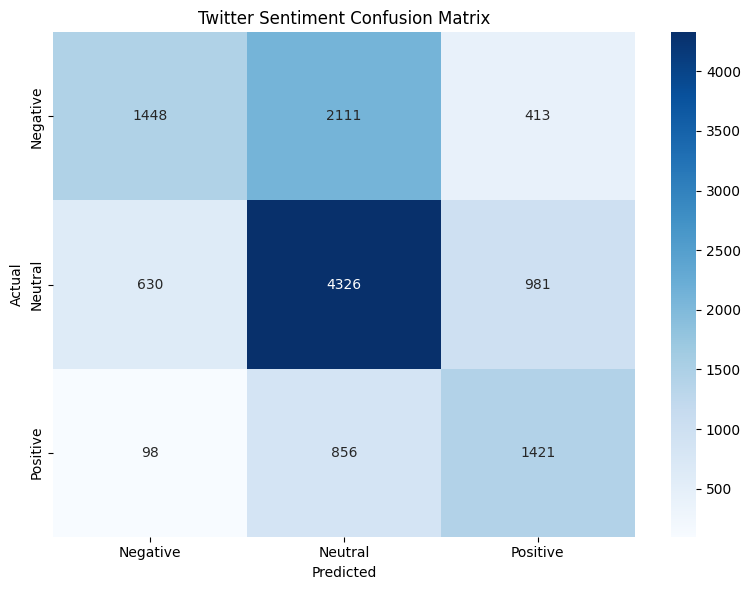

In [55]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:
   - Amazon F1: ... | Twitter F1: ...
   - Reason: ...

2. Character n-gram choices:
   - ngram_range=___ because...
   - Advantage over words: ...

3. Most confused class:
   - Class: ...
   - Reason: ...

4. Difficult tweet example:
   - Tweet: "..."
   - Why it's hard: ...

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [58]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")

arxiv = load_dataset("ccdv/arxiv-summarization")

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...


README.md:   0%|          | 0.00/3.96k [00:00<?, ?B/s]

section/train-00000-of-00015.parquet:   0%|          | 0.00/230M [00:00<?, ?B/s]

section/train-00001-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

section/train-00002-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]

Loaded 2000 papers
Columns: ['article', 'abstract']


In [59]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
we study the effect of @xmath0-symmetric complex potentials on the transport properties of non - hermitian systems , which consist of an infinite linear chain and two side - coupled defect points with @xmath0-symmetric complex on - site potentials . by analytically solving the scattering problem of two typical models , 
 which display standard fano resonances in the absence of non - hermitian terms , we find that the @xmath0-symmetric imaginary potentials can lead to some pronounced effects on t


In [61]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=2,
    max_df=0.95
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])

print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 5000)


In [63]:
# Train LDA model
n_topics_arxiv = 10  # Scientific papers likely have diverse topics. Choose appropriately (8-12).

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [64]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: method, network, model, algorithm, problem, paper, based, data, approach, analysis, new, code
Topic 1: field, magnetic, flow, velocity, simulation, model, cell, shear, fluid, stress, wall, viscosity
Topic 2: xmath, galaxy, star, mass, cluster, model, line, redshift, density, stellar, high, black
Topic 3: ray, energy, spectrum, source, emission, high, flux, jet, beam, radio, photon, observed
Topic 4: graph, node, group, class, number, random, vertex, network, prove, xmath, polynomial, game
Topic 5: phase, transition, field, temperature, magnetic, xcite, mode, critical, model, energy, effect, dynamic
Topic 6: quark, mass, decay, contribution, production, gauge, physic, process, hadron, correction, qcd, meson
Topic 7: quantum, state, spin, time, xcite, frequency, optical, noise, measurement, xmath, electron, process
Topic 8: wave, planet, stokes, orbit, propagation, intensity, circular, time, cavity, anti, molecule, line
Topic 9: xmath, xcite, state, mod

### Exercise C.1: Interpret ArXiv Topics

In [66]:
# TODO: Assign meaningful labels to each topic based on the keywords

my_arxiv_topic_labels = {
    0: "Machine Learning and Algorithms",
    1: "Fluid Dynamics and Simulations",
    2: "Galaxies and Astrophysics",
    3: "High Energy Astronomy",
    4: "Graph Theory and Networks",
    5: "Phase Transitions and Condensed Matter",
    6: "Particle Physics and QCD",
    7: "Quantum Physics and Optics",
    8: "Waves, Planets, and Orbits",
    9: "Mathematical Physics and Theory"
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Machine Learning and Algorithms
  Topic 1: Fluid Dynamics and Simulations
  Topic 2: Galaxies and Astrophysics
  Topic 3: High Energy Astronomy
  Topic 4: Graph Theory and Networks
  Topic 5: Phase Transitions and Condensed Matter
  Topic 6: Particle Physics and QCD
  Topic 7: Quantum Physics and Optics
  Topic 8: Waves, Planets, and Orbits
  Topic 9: Mathematical Physics and Theory


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [ ]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("hugsid/legal-contracts")


In [79]:
legal_df = pd.DataFrame(legal_stream['train']).head(1000)
print(f"Loaded {len(legal_df)} contracts")

Loaded 1000 contracts


In [76]:
legal_stream['train']

Dataset({
    features: ['text'],
    num_rows: 26539
})

In [81]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
supplement joinder agreement agreement dated september made among triangle capital corporation maryland corporation borrower guarantor party credit agreement referred branch banking trust company administrative agent swingline lender existing lender pursuant credit agreement administrative agent uni


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [83]:
# TODO: Create TF-IDF vectorizer for NMF (NMF works better with TF-IDF)

tfidf_legal = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=2,
    max_df=0.95
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])

print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1000, 2199)


In [85]:
# TODO: Train NMF model
# Choose number of topics (legal contracts may have: employment, confidentiality, IP, services, etc.)

n_topics_legal = 8  # YOUR CHOICE: 5-12

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [86]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: agent, administrative, lender, shall, borrower, payment, tax, notice, time, account, hereunder, withholding
Topic 1: subsidiary, company, person, insurance, financial, statement, consolidated, material, asset, business, property, indebtedness
Topic 2: rate, day, advance, period, loan, base, eurodollar, eurocurrency, borrowing, shall, date, business
Topic 3: lender, commitment, loan, revolving, assignment, defaulting, swing, line, shall, obligation, issuing, credit
Topic 4: date, representation, warranty, correct, true, earlier, material, effect, receivables, giving, qualified, respect
Topic 5: agreement, time, credit, partnership, restated, trust, amended, term, dated, gpt, thereto, property
Topic 6: plan, erisa, code, section, affiliate, pension, multiemployer, contribution, employer, borrower, expected, meaning
Topic 7: party, document, agreement, loan, obligation, person, transaction, action, law, proceeding, right, hereto


In [88]:
# TODO: Assign labels to legal topics

my_legal_topic_labels = {
    0: "Payments, Taxes, and Borrower Obligations",
    1: "Corporate Assets and Financial Reporting",
    2: "Loans, Interest Rates, and Borrowing Terms",
    3: "Lending Commitments and Credit Facilities",
    4: "Representations and Warranties",
    5: "Credit Agreements and Contract Amendments",
    6: "Employee Benefits and ERISA Compliance",
    7: "Legal Obligations and Dispute Resolution"
}

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Payments, Taxes, and Borrower Obligations
  Topic 1: Corporate Assets and Financial Reporting
  Topic 2: Loans, Interest Rates, and Borrowing Terms
  Topic 3: Lending Commitments and Credit Facilities
  Topic 4: Representations and Warranties
  Topic 5: Credit Agreements and Contract Amendments
  Topic 6: Employee Benefits and ERISA Compliance
  Topic 7: Legal Obligations and Dispute Resolution


### Exercise C.3: Topic Distribution Visualization

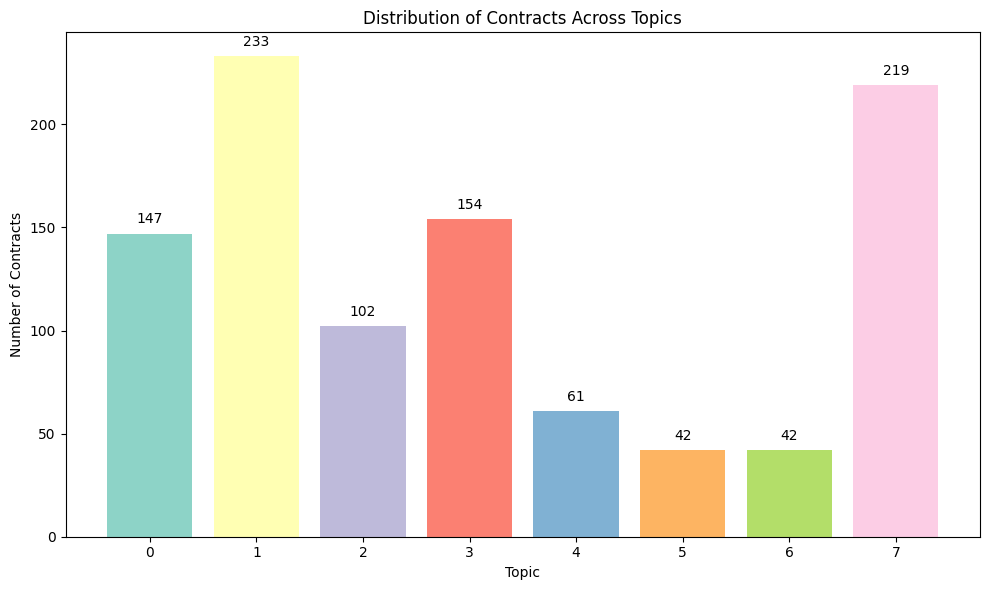

In [89]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: ...
   - Reason: ...

2. Legal topic distribution:
   - Balanced? ...
   - What this indicates: ...

3. Topic refinement suggestions:
   - ArXiv - Merge: Topics ___ and ___ because...
   - ArXiv - Split: Topic ___ because...
   - Legal - Merge: Topics ___ and ___ because...
   - Legal - Split: Topic ___ because...

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
